# GB chain post-processing

Loads the Eryn HDF backend from `gb_test_script_td_wave.py` (in-progress chain is fine — it reads whatever has been saved so far).

Chain dims: `ntemps=2`, `nwalkers=2`, 8 sampled parameters in the order:
`amp, f0, fdot0, phi0, cosinc, psi, lam, sinbeta`.

`fddot0` is held fixed at 0 by the `fill_dict` transform — it's part of the full physics basis but not sampled.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from eryn.backends import HDFBackend

CHAIN_PATH = os.path.expanduser(
    "~/Documents/LISA/LISA_Sprint_2026/lisasprint26/lisa_sprint_2026/base_shorter_test_gb_pe.h5"
)
backend = HDFBackend(CHAIN_PATH)
print(f"Loaded: {CHAIN_PATH}")

Loaded: /Users/oliverda/Documents/LISA/LISA_Sprint_2026/lisasprint26/lisa_sprint_2026/base_shorter_test_gb_pe.h5


## 1. Chain shape and bookkeeping

In [2]:
chain = backend.get_chain()
log_like = backend.get_log_like()
log_prior = backend.get_log_prior()

gb = chain["gb"]
print("chain['gb'] shape:", gb.shape, "-> (nsteps_saved, ntemps, nwalkers, nleaves, ndim)")
print("log_like shape:   ", log_like.shape)
print("log_prior shape:  ", log_prior.shape)
print("iteration:        ", backend.iteration)

nsteps_saved, ntemps, nwalkers, nleaves, ndim = gb.shape
print(f"\nUseful: {nsteps_saved} saved steps x {nwalkers} walkers = {nsteps_saved * nwalkers} cold-chain samples per parameter.")

chain['gb'] shape: (278, 2, 2, 1, 8) -> (nsteps_saved, ntemps, nwalkers, nleaves, ndim)
log_like shape:    (278, 2, 2)
log_prior shape:   (278, 2, 2)
iteration:         278

Useful: 278 saved steps x 2 walkers = 556 cold-chain samples per parameter.


In [3]:
PARAM_NAMES = [
    "amp", "f0", "fdot0", "phi0", "cosinc", "psi", "lam", "sinbeta",
]
assert len(PARAM_NAMES) == ndim, f"name list ({len(PARAM_NAMES)}) doesn't match ndim ({ndim})"

# Color scheme used throughout this notebook
INJ_COLOR = "purple"
REC_COLOR = "orange"

# Injection values from gb_test_script_td_wave.py
INJECTED = {
    "amp":     8.0e-23,
    "f0":      20.0e-3,
    "fdot0":   1.0e-14,
    "phi0":    2.09802430298,
    "cosinc":  np.cos(0.23984234),
    "psi":     1.234019814,
    "lam":     4.09808143,
    "sinbeta": np.sin(0.090),
}
truth = np.array([INJECTED[n] for n in PARAM_NAMES])

## 2. Acceptance fraction

Crude diagnostic: fraction of proposed moves that were accepted, per walker, on the cold chain. For StretchMove, you want this to be roughly 0.2-0.5. Values near 0 or 1 mean the proposal is poorly scaled.

In [4]:
try:
    af = backend.get_autocorr_time()
    print("autocorr times (per param, cold temp):")
    print(af)
except Exception as e:
    print("autocorr not yet usable:", e)

try:
    accept = backend.accepted  # shape (ntemps, nwalkers) cumulative
    print("\ncumulative acceptances (ntemps, nwalkers):\n", accept)
    print("fraction (vs iteration):", accept / max(backend.iteration, 1))
except AttributeError:
    print("backend.accepted not available in this Eryn version")

autocorr not yet usable: get_autocorr_time is not well-defined for number of temperatures > 1 or when using reversible jump.

cumulative acceptances (ntemps, nwalkers):
 [[122. 121.]
 [110. 106.]]
fraction (vs iteration): [[0.43884892 0.4352518 ]
 [0.39568345 0.38129496]]


## 3. Trace plots

Cold-temperature chain (index 0). Each color is a walker; horizontal dashed line is the injected value. With only a handful of steps this just shows the chain hasn't blown up.

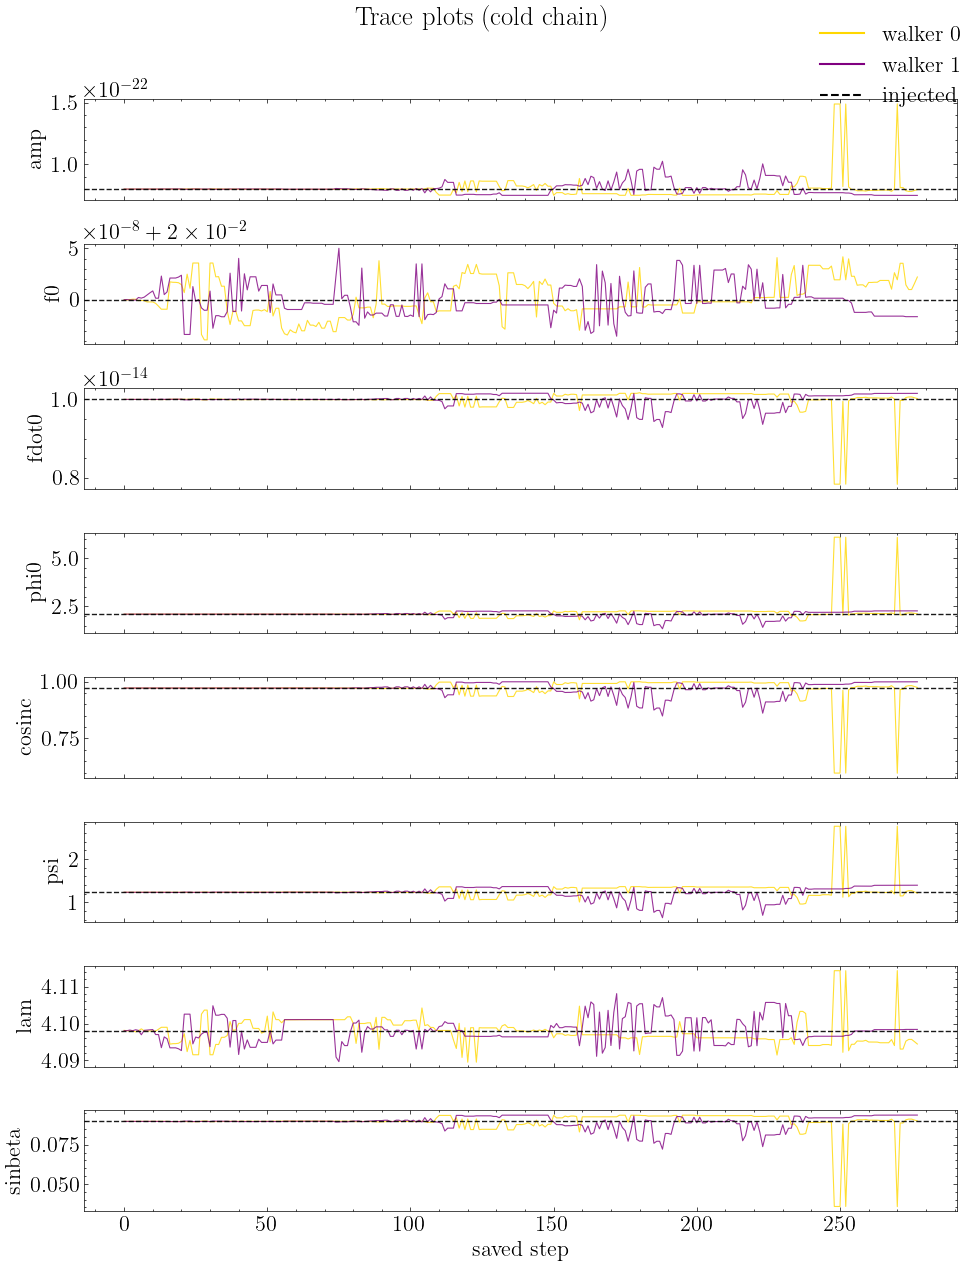

In [5]:
from matplotlib.lines import Line2D

cold = gb[:, 0, :, 0, :]  # (nsteps_saved, nwalkers, ndim)

WALKER_COLORS = ["gold", "purple"]
TRACE_INJ_COLOR = "black"

fig, axes = plt.subplots(ndim, 1, figsize=(10, 1.6 * ndim), sharex=True)
for i, name in enumerate(PARAM_NAMES):
    ax = axes[i]
    for w in range(nwalkers):
        ax.plot(cold[:, w, i], lw=0.8, alpha=0.8,
                color=WALKER_COLORS[w % len(WALKER_COLORS)])
    ax.axhline(truth[i], ls="--", color=TRACE_INJ_COLOR, lw=1.0, alpha=0.9)
    ax.set_ylabel(name)
axes[-1].set_xlabel("saved step")

legend_handles = [
    Line2D([0], [0], color=WALKER_COLORS[w % len(WALKER_COLORS)], lw=1.5,
           label=f"walker {w}")
    for w in range(nwalkers)
] + [
    Line2D([0], [0], color=TRACE_INJ_COLOR, lw=1.5, ls="--", label="injected"),
]
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(1.0, 1.0))
fig.suptitle("Trace plots (cold chain)", y=1.0)
fig.tight_layout()

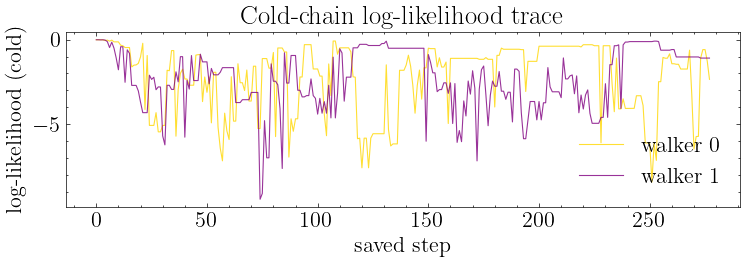

In [6]:
cold_ll = log_like[:, 0, :]  # (nsteps, nwalkers)
fig, ax = plt.subplots(figsize=(8, 3))
for w in range(nwalkers):
    ax.plot(cold_ll[:, w], lw=0.8, alpha=0.8,
            color=WALKER_COLORS[w % len(WALKER_COLORS)],
            label=f"walker {w}")
ax.set_xlabel("saved step")
ax.set_ylabel("log-likelihood (cold)")
ax.legend(loc="best")
ax.set_title("Cold-chain log-likelihood trace")
fig.tight_layout()

## 4. Corner plot

Flattens cold chain across walkers. With this many samples it's not a posterior — it's a scatter plot. Re-run after a longer chain for anything to interpret here.

Optional discard: drop the first `discard` steps as burn-in.

flat samples shape: (556, 8)


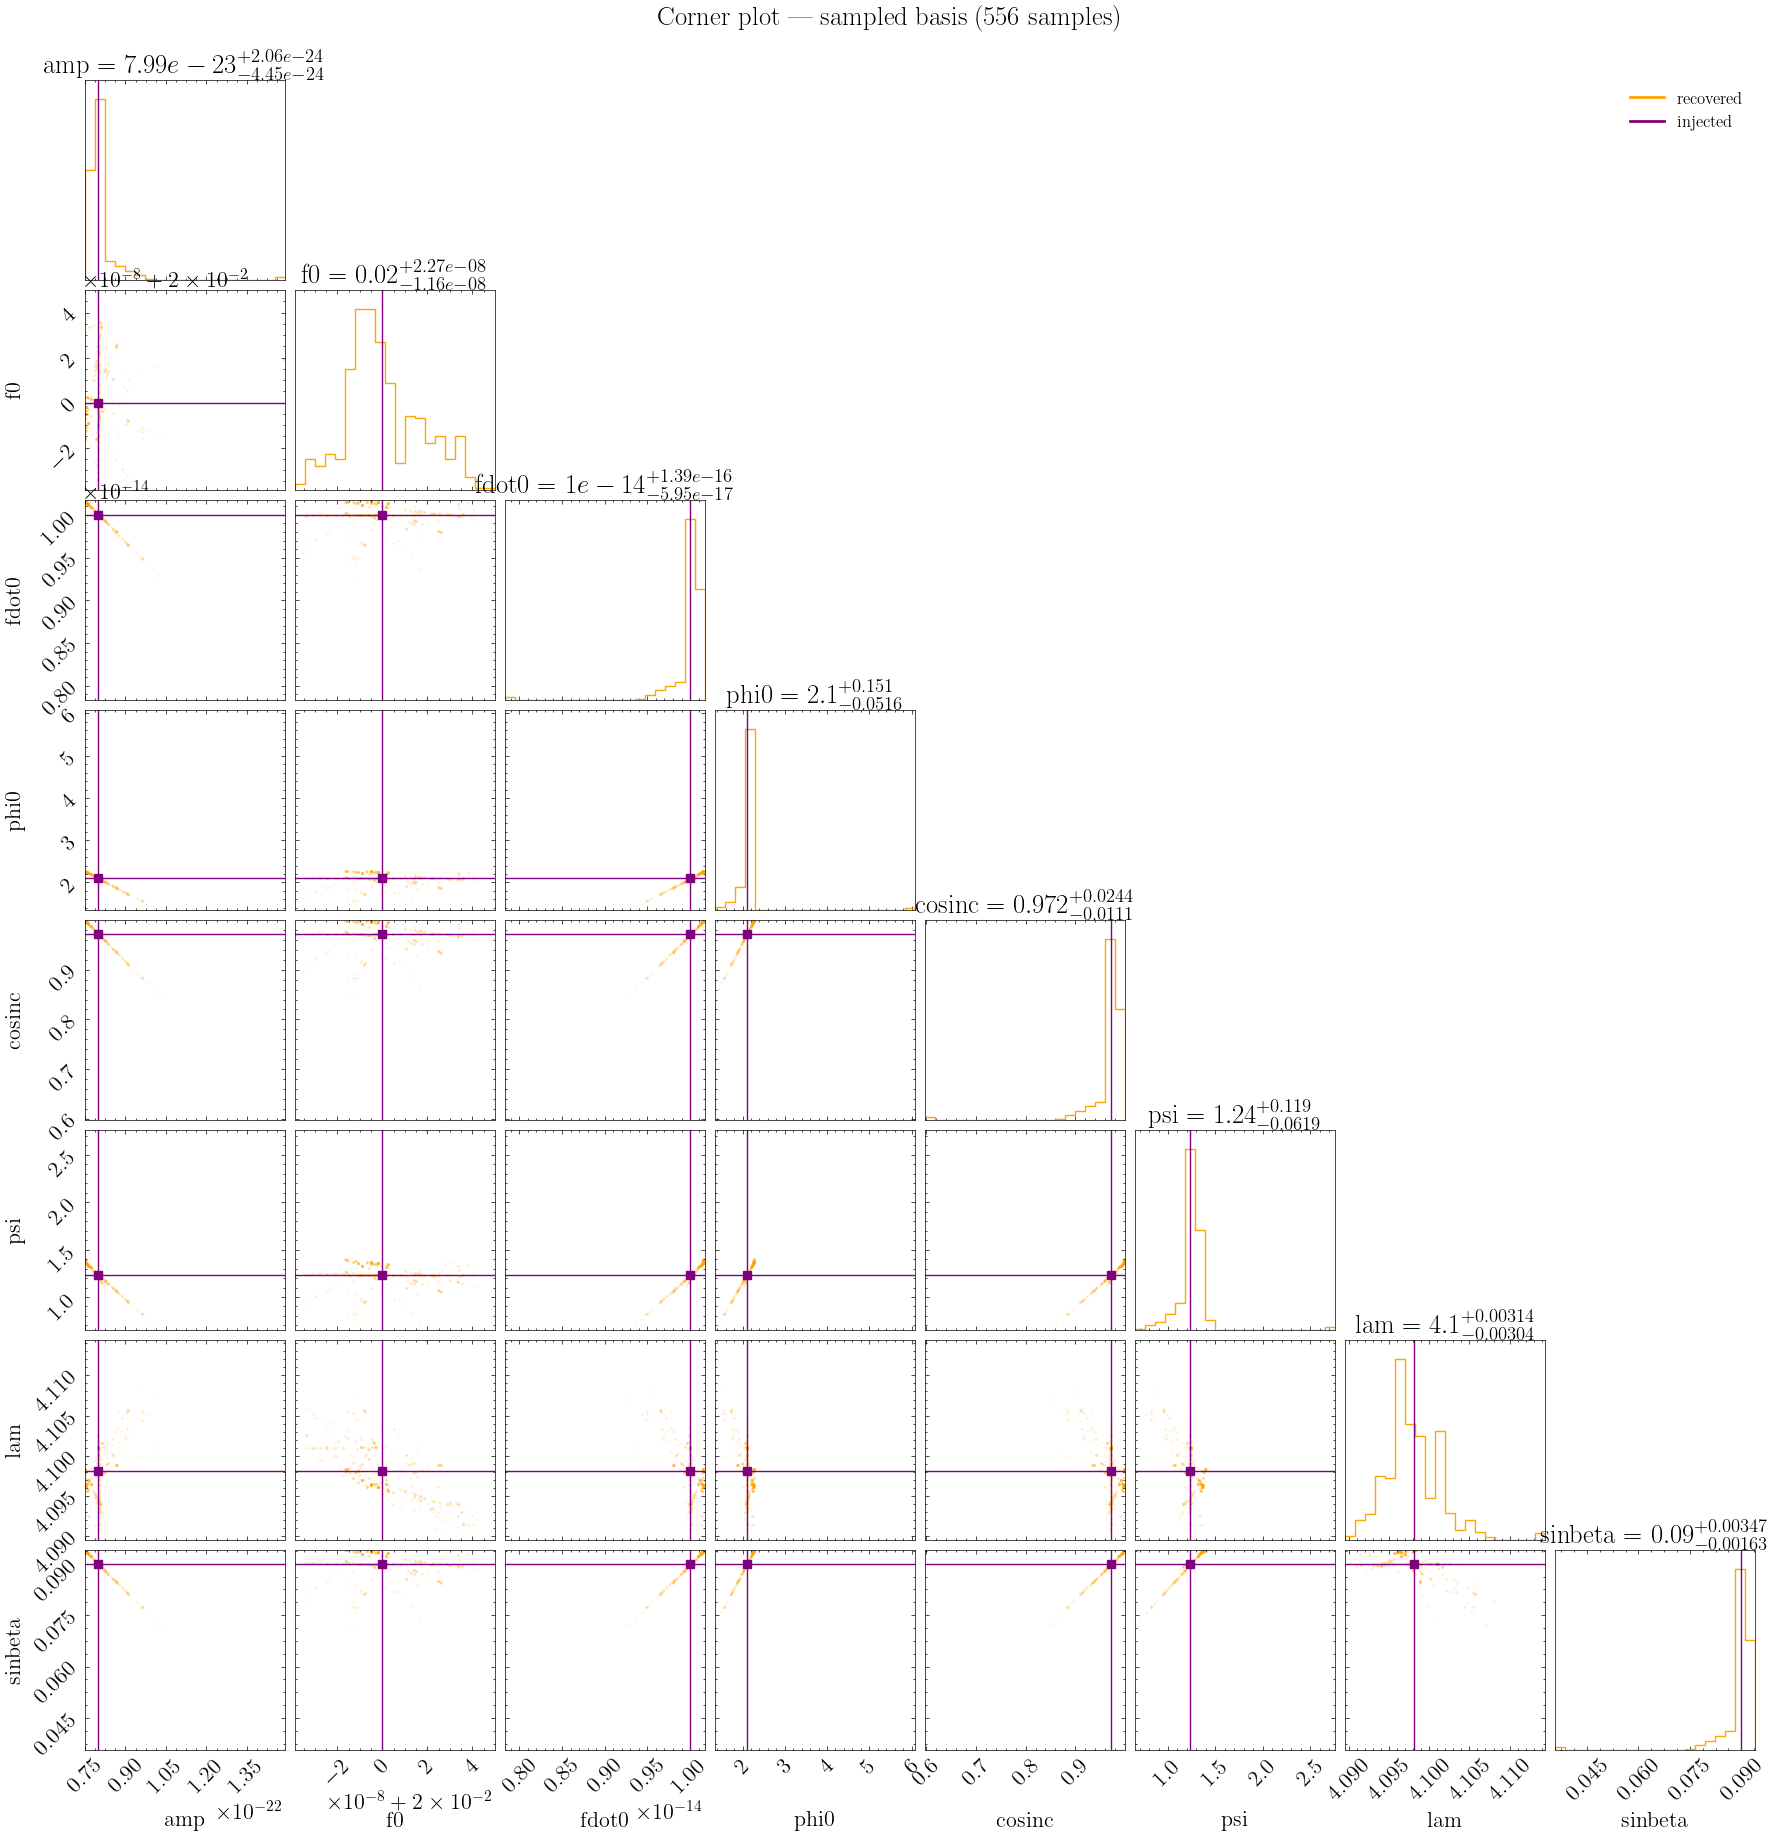

In [7]:
from matplotlib.lines import Line2D

discard = 0
flat = cold[discard:].reshape(-1, ndim)
print("flat samples shape:", flat.shape)

try:
    import corner
    fig = corner.corner(
        flat,
        labels=PARAM_NAMES,
        truths=truth,
        show_titles=True,
        title_fmt=".3g",
        plot_density=False,
        plot_contours=False,    # set True once you have enough samples
        plot_datapoints=True,
        color=REC_COLOR,
        truth_color=INJ_COLOR,
        hist_kwargs=dict(color=REC_COLOR),
    )
    legend_handles = [
        Line2D([0], [0], color=REC_COLOR, lw=2, label="recovered"),
        Line2D([0], [0], color=INJ_COLOR, lw=2, label="injected"),
    ]
    fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=12)
    fig.suptitle(f"Corner plot — sampled basis ({flat.shape[0]} samples)", y=1.02)
except ImportError:
    print("`corner` not installed in this env — `pip install corner`")

## 5. Sampled basis -> physical basis

The sampler walks in `cosinc, sinbeta`. Invert those for physical inclination and ecliptic latitude. `fddot0` is held at 0 by the script, not sampled.

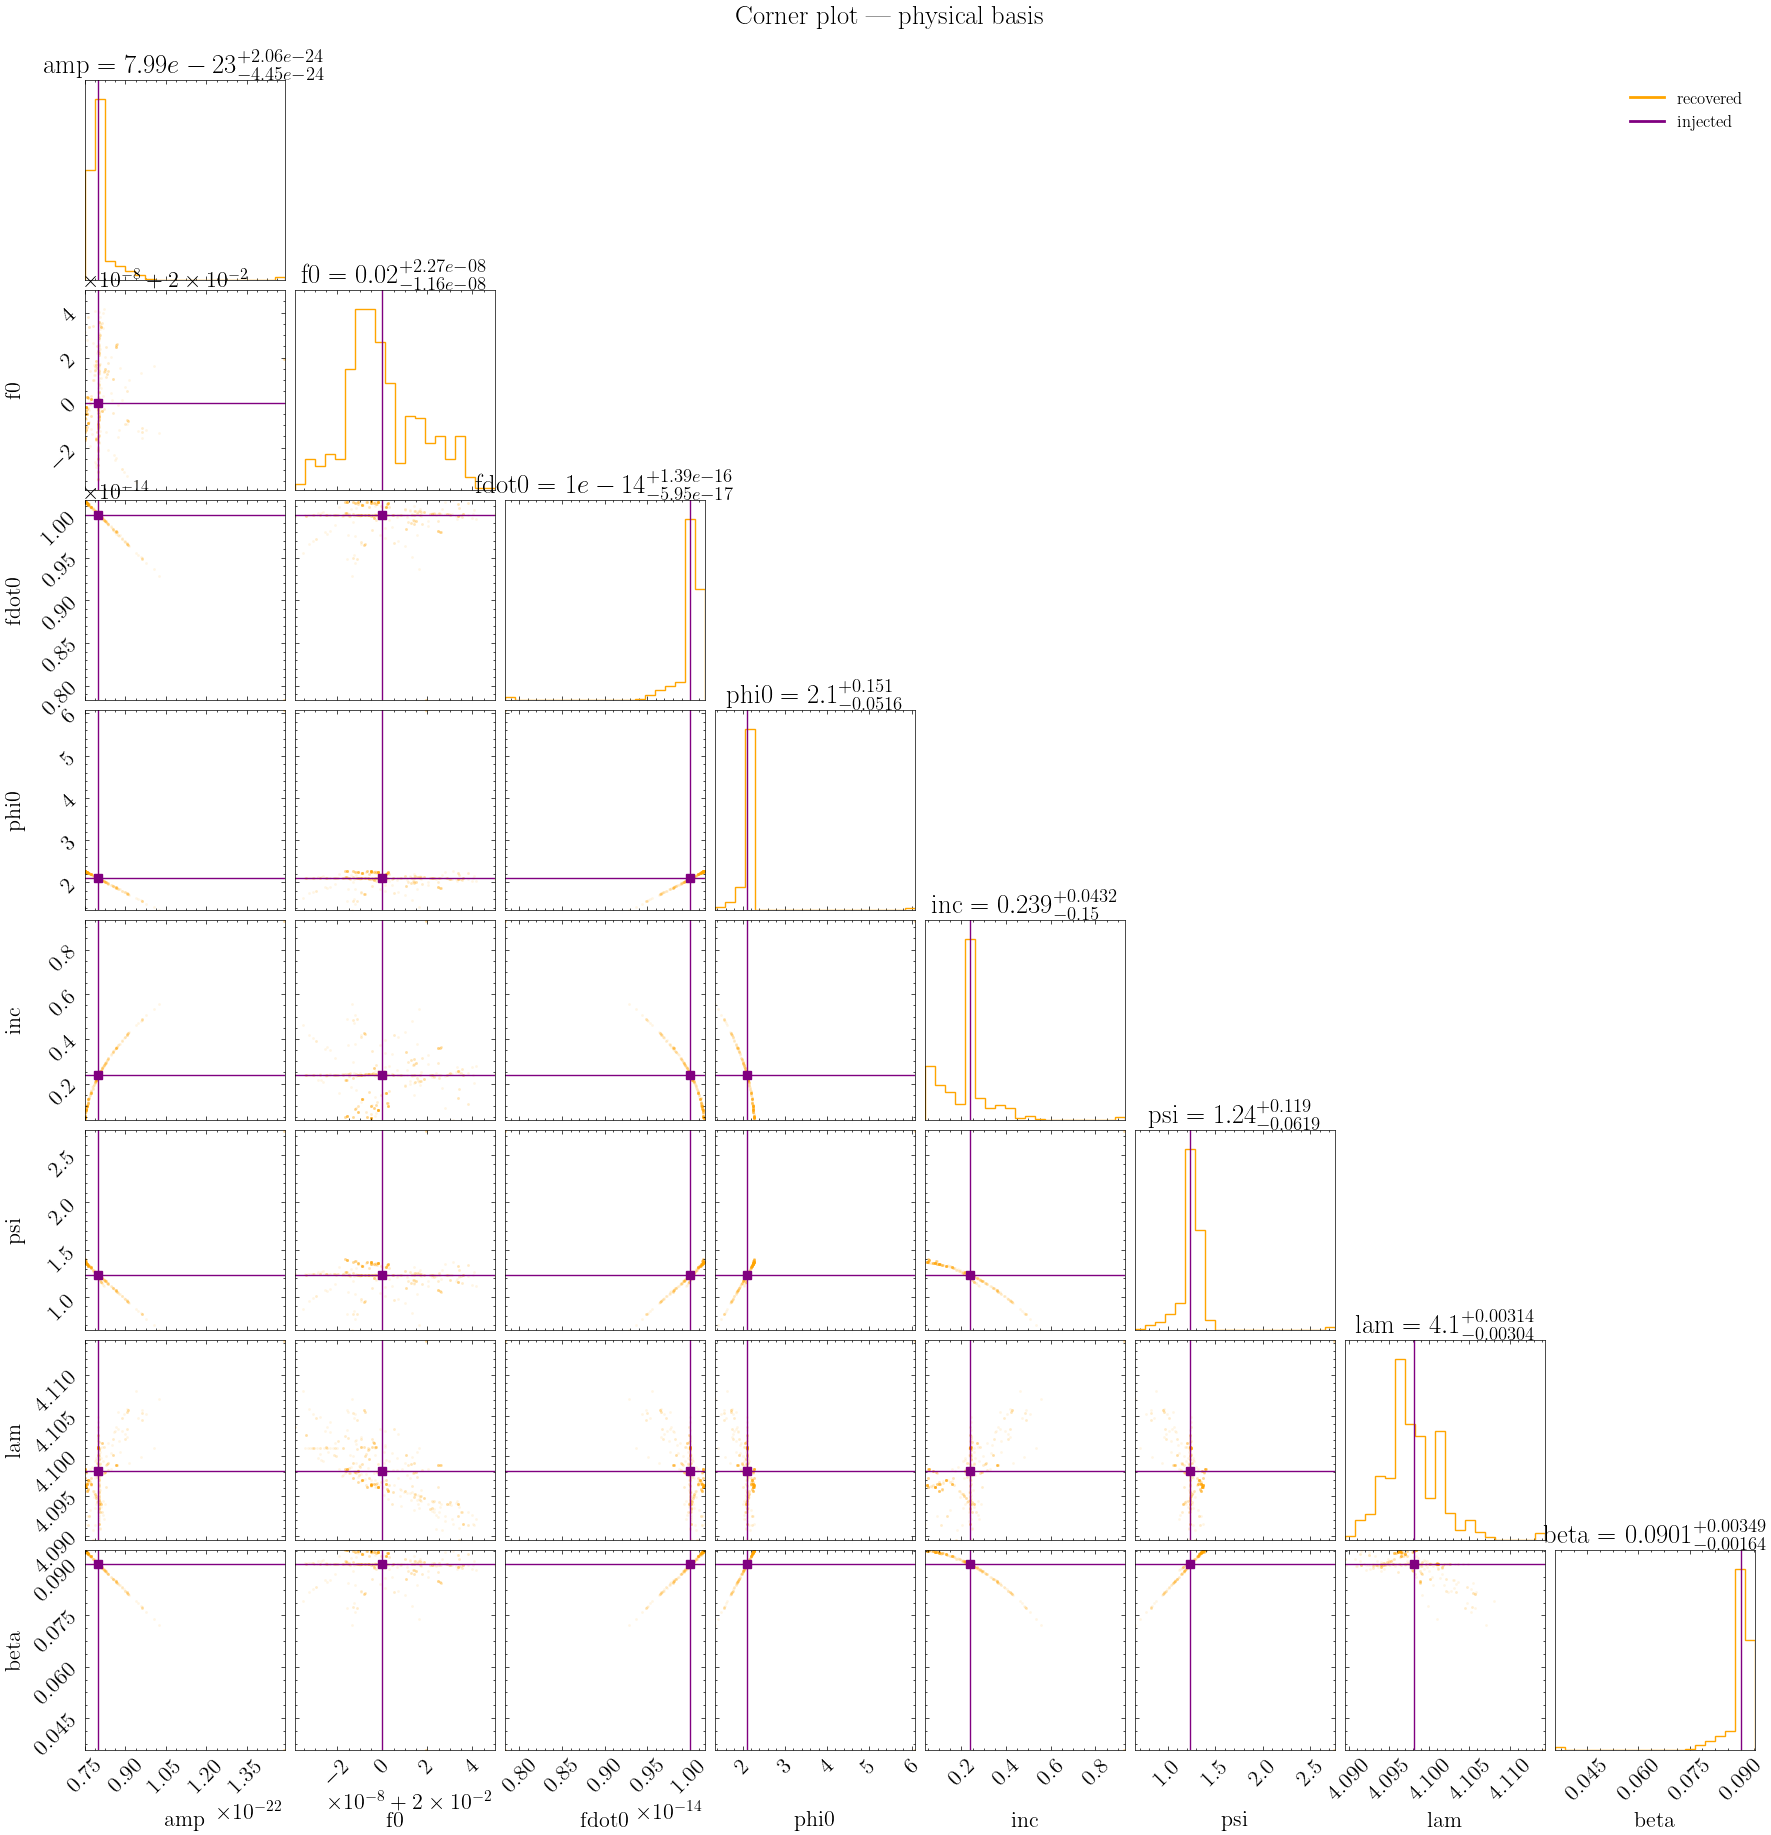

In [8]:
from matplotlib.lines import Line2D

inc_s = np.arccos(flat[:, PARAM_NAMES.index("cosinc")])
beta_s = np.arcsin(flat[:, PARAM_NAMES.index("sinbeta")])

physical = np.column_stack([
    flat[:, PARAM_NAMES.index("amp")],
    flat[:, PARAM_NAMES.index("f0")],
    flat[:, PARAM_NAMES.index("fdot0")],
    flat[:, PARAM_NAMES.index("phi0")],
    inc_s,
    flat[:, PARAM_NAMES.index("psi")],
    flat[:, PARAM_NAMES.index("lam")],
    beta_s,
])
PHYSICAL_NAMES = ["amp", "f0", "fdot0", "phi0", "inc", "psi", "lam", "beta"]
physical_truth = np.array([
    8.0e-23, 20.0e-3, 1.0e-14, 2.09802430298,
    0.23984234, 1.234019814, 4.09808143, 0.090,
])

try:
    import corner
    fig = corner.corner(
        physical,
        labels=PHYSICAL_NAMES,
        truths=physical_truth,
        show_titles=True,
        title_fmt=".3g",
        plot_density=False,
        plot_contours=False,
        plot_datapoints=True,
        color=REC_COLOR,
        truth_color=INJ_COLOR,
        hist_kwargs=dict(color=REC_COLOR),
    )
    legend_handles = [
        Line2D([0], [0], color=REC_COLOR, lw=2, label="recovered"),
        Line2D([0], [0], color=INJ_COLOR, lw=2, label="injected"),
    ]
    fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=12)
    fig.suptitle("Corner plot — physical basis", y=1.02)
except ImportError:
    pass

## 6. Suggestions

- This chain reads whatever has been saved so far — re-run the notebook to refresh as the run progresses.
- **Longer chains:** the default `nsteps=2000` is already in `gb_test_script_td_wave.py`. The script writes incrementally to `test_gb_pe.h5` and the `if os.path.exists(fp)` branch resumes from the last sample, so Ctrl-C is safe.
- **More walkers/temps:** `nwalkers=2` is below the StretchMove rule of thumb (>= 2*ndim, so >=16 for 8 params).
- **Autocorrelation:** once you have many autocorr-times worth of samples, `backend.get_autocorr_time()` will stop raising.
- **Sensible burn-in:** look at the log-likelihood trace and discard everything before it plateaus — set `discard` in the corner-plot cell.